#### AnalystLab Africa

# Projet d'analyse des ventes d'une entreprise e-commerce

In [3]:
#Importation des bibliothèques 
import pandas as pd
import numpy as np

In [4]:
#Importation du ficher
#On a utilisé encoding parce qu'il y a des caractères spéciaux, sans quoi pandas ne peut pas les lire
df = pd.read_csv(r"C:\Users\HP ProBook\Desktop\AnalystLab Africa\OnlineRetail.csv", encoding="latin1")

## Familarisation avec le jeu de données

In [5]:
#Affichons les première lignes
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
#Nombre de lignes et de colonnes
df.shape

(541909, 8)

In [7]:
#Information sur chaque colonnes, valeur null et types de données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [8]:
#Variable numériques
variables_numeriques = df.select_dtypes(include=["int16", "float64"])
print("variables numeriques :")
print(variables_numeriques.columns.tolist())



variables numeriques :
['UnitPrice', 'CustomerID']


In [9]:
#Variables catégorielles
variables_categorielles = df.select_dtypes(include=["str"])
print("Variables catégorielles :")
print(variables_categorielles.columns.tolist())

Variables catégorielles :
['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


## Nettoyage des données

In [10]:
#Verifions s'il y a des valeurs nulles
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
#Analyse des lignes où Description est nulle
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [12]:
#Suppression des valeurs nulles de Description
df = df.dropna(subset=["Description"])


In [13]:
#vérification
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

Traitement des valeurs manquantes (Description)
La colonne Description contenait 1 454 valeurs manquantes. Après investigation, ces enregistrements présentaient également un prix unitaire égal à 0, un CustomerID manquant, et correspondaient à des transactions qui ne représentaient pas des ventes exploitables pour l'analyse. Comme ces lignes représentaient une très faible proportion du jeu de données (moins de 1 %), elles ont été supprimées afin de garantir la qualité et la pertinence des analyses.

In [14]:
#Affichons les lignes où CustomerID est null
df[df["CustomerID"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom


Traitement des valeurs manquantes de CustomerID
Une analyse des lignes présentant un CustomerID manquant a montré que les autres informations de la transaction (description du produit, quantité, prix unitaire, numéro de facture, date et pays) étaient correctement renseignées. Ces enregistrements correspondent donc à des transactions valides, mais dont le client n'a pas été identifié. Afin de préserver l'intégralité des données de vente, ces lignes ont été conservées dans le jeu de données principal. Elles seront uniquement exclues des analyses nécessitant l'identification des clients.

In [15]:
#Voyons si nous avons des doublons
df.duplicated().sum() 

np.int64(5268)

In [16]:
# Vérification des doublons en les classant par n° de facture(InvoiceNo)
df[df.duplicated(keep=False)].sort_values(by="InvoiceNo").head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
604,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.65,17920.0,United Kingdom
605,536412,22902,TOTE BAG I LOVE LONDON,7,12/1/2010 11:49,2.10,17920.0,United Kingdom


In [17]:
#Dernière vérification, (séléction de toutes les lignes impliqués dans un doublons
df[df.duplicated(keep=False)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [18]:
# Suppression des doublons
df = df.drop_duplicates()

In [19]:
#Assurons nous de la suppresion des doublons
df.duplicated().sum()

np.int64(0)

Une vérification des doublons a révélé 5 268 lignes dupliquées. Après examen, ces enregistrements étaient des doublons complets (toutes les colonnes identiques). Ils ont donc été supprimés afin de garantir l'intégrité du jeu de données et d'éviter un double comptage lors des analyses.

In [20]:
#Affichons les transactions ayant une quantité négative
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [21]:
#Comptons le nombre de transactions ayant une quantité négative
(df["Quantity"] < 0).sum()

np.int64(9725)

In [22]:
#Afficher les 1O premières lignes ayant une quantité négatve
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


Observation :  

Les transactions ayant une quantité négative sont principalement associées à des numéros de facture commençant par "C", ce qui indique des commandes annulées ou des retours de marchandises. De plus, certains StockCode spéciaux comme "D" correspondent à des remises (Discount) et non à des produits.

In [23]:
#Affichons les transactions ayant un prix unitaire nuls ou négatifs
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [24]:
#Suppression des transactions correspondant à des ajustements comptables
#cette suppression est en fait un filtrage
df = df[df["UnitPrice"] >= 0]

In [25]:
#Vérification
(df["UnitPrice"] < 0).sum()

np.int64(0)

Traitement des prix unitaires négatifs  
Une vérification de la colonne UnitPrice a révélé deux enregistrements présentant des prix unitaires négatifs. Après analyse, ces transactions correspondaient à des ajustements comptables ("Adjustment by debit") et non à des ventes réelles. Étant donné que l'objectif de cette étude est d'analyser les ventes du commerce électronique, ces deux lignes ont été supprimées afin de conserver uniquement les transactions commerciales pertinentes.

In [26]:
#Affichons les transactions où le prix unitaire est égal à 0
df[df["UnitPrice"] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,12/3/2010 12:08,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,12/3/2010 12:08,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,12/3/2010 16:50,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/2010 14:02,0.0,12647.0,Germany
13217,537425,84968F,check,-20,12/6/2010 15:35,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom


In [27]:
#Nombre total des transactions où le prix unitaire est égal à 0
(df["UnitPrice"] == 0).sum()

np.int64(1056)

In [28]:
# Afficher les transactions avec un prix unitaire égal à 0 et une quantité positive
df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,12/3/2010 12:08,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,12/3/2010 12:08,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/2010 14:02,0.0,12647.0,Germany
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,12/7/2010 11:48,0.0,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,12/7/2010 11:48,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524622,580609,22927,Amazon,1,12/5/2011 11:41,0.0,NaN,United Kingdom
535325,581202,23404,check,41,12/7/2011 18:30,0.0,NaN,United Kingdom
535334,581211,22142,check,14,12/7/2011 18:36,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom


In [29]:
# Compter les transactions avec un prix unitaire égal à 0 et une quantité positive
((df["UnitPrice"] == 0) & (df["Quantity"] > 0)).sum()

np.int64(582)

### Traitement des prix unitaires égaux à zéro  
Une analyse des transactions dont le prix unitaire est égal à zéro a été réalisée. Les résultats montrent que ces enregistrements concernent différents produits et présentent à la fois des quantités positives et négatives. Aucune preuve ne permet de conclure qu'il s'agit uniquement d'erreurs ou d'ajustements comptables. Afin de préserver l'intégrité du jeu de données, ces transactions ont été conservées. Elles pourront être étudiées plus en détail dans des analyses spécifiques si nécessaire.

In [30]:
#Standarisation
#Convertion de la colonne InvoiceDate au format Date/Heure
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [31]:
#Vérification
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [32]:
#Extrairaction de l'année, du mois, et le jour à partir de la date de transaction
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

# Analyse exploiratoire des données

In [33]:
#Calculons le chiffre d'affaire de chaque transaction
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [34]:
#Vérification
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [35]:
#statistique descriptive(Numerique)
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Year,Month,Day,Revenue
count,535185.000000,535185,535185.000000,401604.000000,535185.000000,535185.000000,535185.000000,535185.000000
mean,9.671626,2011-07-04 11:43:31.850892,4.686598,15281.160818,2010.921792,7.548395,15.023356,18.214507
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,2010.000000,1.000000,1.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13939.000000,2011.000000,5.000000,7.000000,3.750000
50%,3.000000,2011-07-19 15:38:00,2.080000,15145.000000,2011.000000,8.000000,15.000000,9.900000
75%,10.000000,2011-10-19 08:20:00,4.130000,16784.000000,2011.000000,11.000000,22.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,2011.000000,12.000000,31.000000,168469.600000
std,219.059465,NaN,94.985568,1714.006089,0.268500,3.508457,8.660448,380.570230


In [36]:
#statistique descriptive(Numerique)
df.describe(include="str")


,InvoiceNo,StockCode,Description,Country
count,535185,535185,535185,535185
unique,24444,3958,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2301,2357,488844


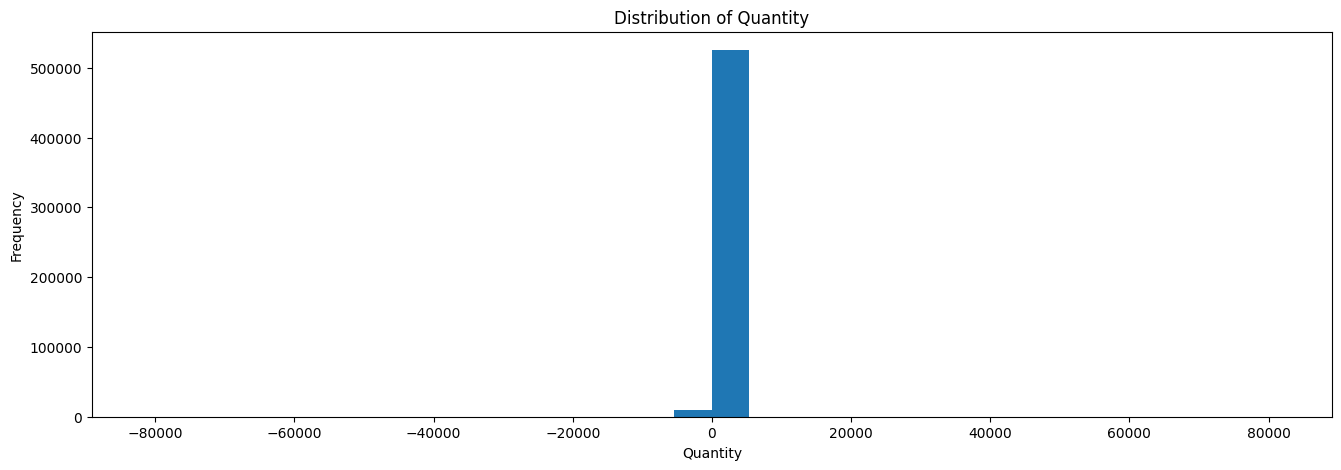

In [37]:
#Visualisation de la distribution des quantités vendues
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,5))
plt.hist(df["Quantity"], bins=30)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

In [38]:
# Afficher les valeurs minimale et maximale de la quantité
df["Quantity"].min(), df["Quantity"].max()

(np.int64(-80995), np.int64(80995))

# Analyse des métriques clés

In [39]:
#Chiffres d'affaire total
df["Revenue"].sum()

np.float64(9748131.074000001)

In [40]:
#Chiffre d'affaire total en mettant les virgules pour séparer
total_Revenue = df["Revenue"].sum()
print(f"Total revenue : {total_Revenue:,.2f}")


Total revenue : 9,748,131.07


In [41]:
#Nombre de transaction total(ici on compte les factures unique et non le nbre de lignes)
df["InvoiceNo"].nunique()

24444

In [42]:
#comptons le nombre de produits différents
df["StockCode"].nunique()

3958

In [43]:
#Comptons le nombre de clients uniques
df["CustomerID"].nunique()

4372

# Analyse des performance

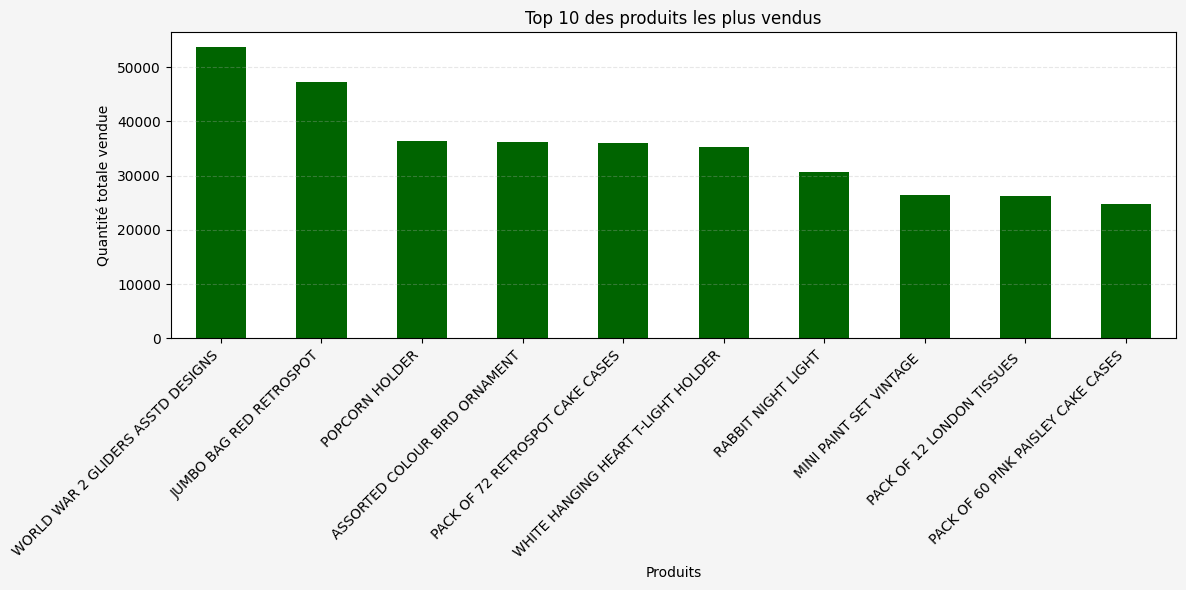

In [44]:
# Calculer les 10 produits les plus vendus en fonction de la quantité
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Créer une figure avec un fond gris très clair
plt.figure(figsize=(12,6), facecolor="whitesmoke")

# Tracer le graphique
top_products.plot(kind="bar", color="darkgreen")

# Ajouter une grille horizontale
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Ajouter le titre et les étiquettes des axes
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Produits")
plt.ylabel("Quantité totale vendue")

# Faire pivoter les noms des produits
plt.xticks(rotation=45, ha="right")

# Ajuster automatiquement la mise en page
plt.tight_layout()

# Afficher le graphique
plt.show()

Insight : Les ventes sont concentrées sur quelques produits. Le produit WORLD WAR 2 GLIDERS ASSTD DESIGNS est le plus vendu avec plus de 53 000 unités, suivi de JUMBO BAG RED RETROSPOT. Ces produits représentent les meilleures performances en volume de vente et devraient être privilégiés pour les actions de réapprovisionnement et de promotion.

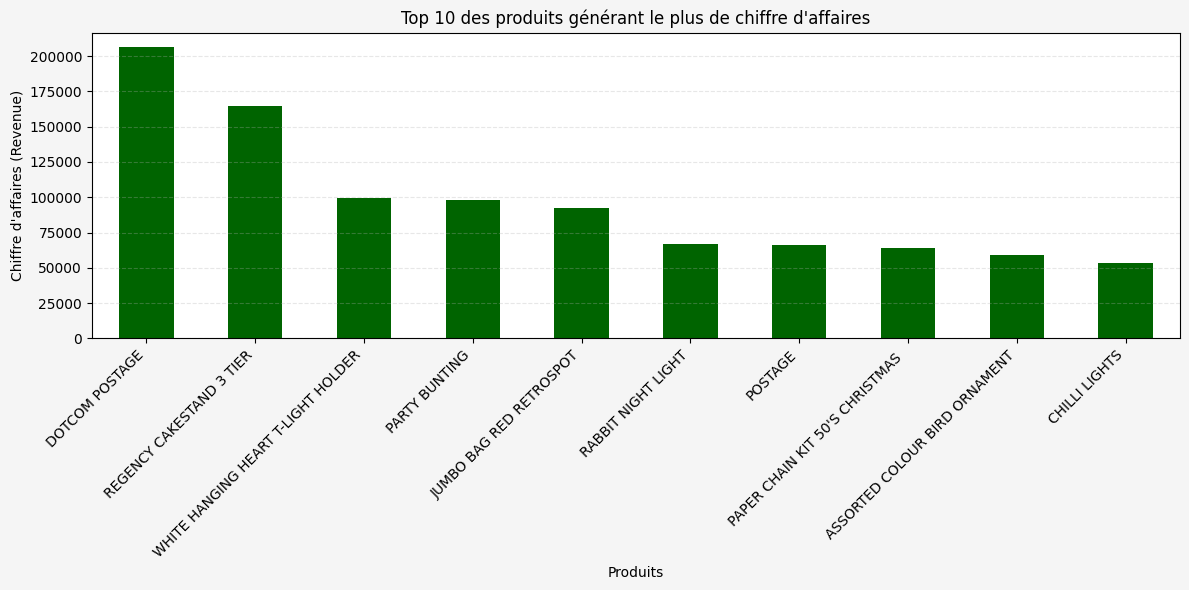

In [45]:
# Calculer les 10 produits générant le plus de chiffre d'affaires
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Créer une figure avec un fond gris très clair
plt.figure(figsize=(12,6), facecolor="whitesmoke")

# Tracer le graphique
top_revenue.plot(kind="bar", color="darkgreen")

# Ajouter une grille horizontale
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Ajouter le titre et les étiquettes des axes
plt.title("Top 10 des produits générant le plus de chiffre d'affaires")
plt.xlabel("Produits")
plt.ylabel("Chiffre d'affaires (Revenue)")

# Faire pivoter les noms des produits
plt.xticks(rotation=45, ha="right")

# Ajuster automatiquement la mise en page
plt.tight_layout()

# Afficher le graphique
plt.show()

Insight : Le produit DOTCOM POSTAGE génère le chiffre d'affaires le plus élevé, devant REGENCY CAKESTAND 3 TIER. Il est intéressant de noter que certains produits figurent parmi les plus rentables sans nécessairement être les plus vendus en quantité. Cela montre que le prix unitaire influence fortement le chiffre d'affaires. L'entreprise devrait donc accorder une attention particulière aux produits à forte valeur ajoutée afin d'optimiser ses revenus.

In [46]:
#Affichons les années présentes dans notre Dataset
df["Year"].unique()

array([2010, 2011], dtype=int32)

In [47]:
#Calculons le chiffre d'affaire mensuel pour chaque année en les regroupant par année et par mois
ca_mensuel = df.groupby(["Year", "Month"])["Revenue"].sum().unstack()
#Affichons le tableau obtenu
ca_mensuel

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,746723.61
2011,558448.56,497026.41,682013.98,492367.841,722094.1,689977.23,680156.991,703510.58,1017596.682,1069368.23,1456145.8,432701.06


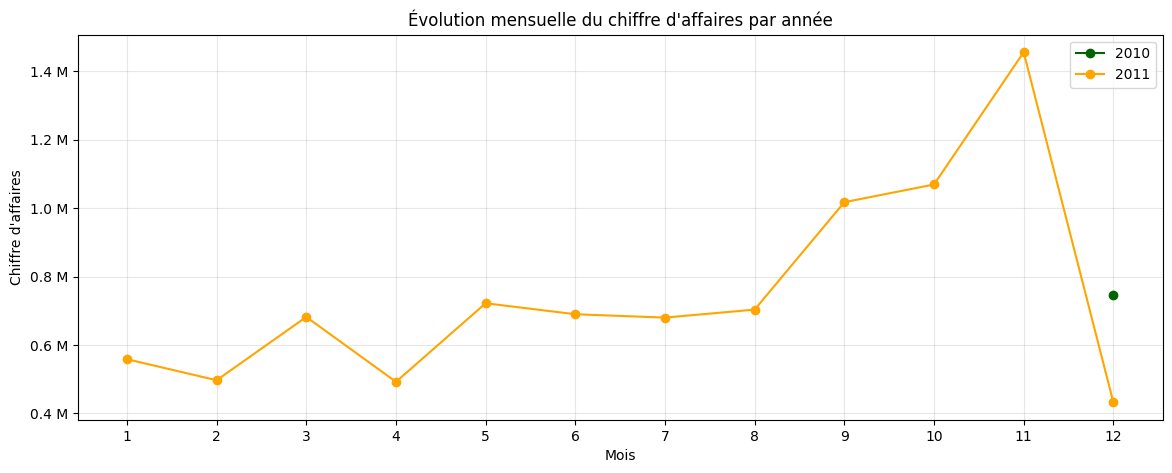

In [48]:
# Créer une nouvelle figure
plt.figure(figsize=(14,5))

# Tracer l'évolution mensuelle du chiffre d'affaires de l'année 2010
plt.plot(
    ca_mensuel.columns,
    ca_mensuel.loc[2010],
    marker='o',
    color='darkgreen',
    label='2010'
)

# Tracer l'évolution mensuelle du chiffre d'affaires de l'année 2011
plt.plot(
    ca_mensuel.columns,
    ca_mensuel.loc[2011],
    marker='o',
    color='orange',
    label='2011'
)
# Afficher les valeurs de l'axe Y en millions
from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} M')
)

# Ajouter le titre du graphique
plt.title("Évolution mensuelle du chiffre d'affaires par année")

# Nom de l'axe horizontal
plt.xlabel("Mois")

# Nom de l'axe vertical
plt.ylabel("Chiffre d'affaires")

# Afficher tous les mois de 1 à 12
plt.xticks(range(1,13))

# Ajouter une grille pour faciliter la lecture
plt.grid(alpha=0.3)

# Afficher la légende
plt.legend()

# Afficher le graphique
plt.show()

Insight : Le graphique montre que les données couvrent deux années distinctes (2010 et 2011). L'année 2010 contient moins d'observations, car elle ne couvre qu'une partie de l'année. En revanche, l'année 2011 présente une évolution complète du chiffre d'affaires. On observe une augmentation progressive des ventes au cours de l'année, avec un pic marqué en novembre, suivi d'une légère baisse en décembre. Cette tendance peut s'expliquer par les achats de fin d'année (Black Friday et fêtes de Noël).

In [49]:
#Chiffre affaire total par pays
country_revenue = (df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10))

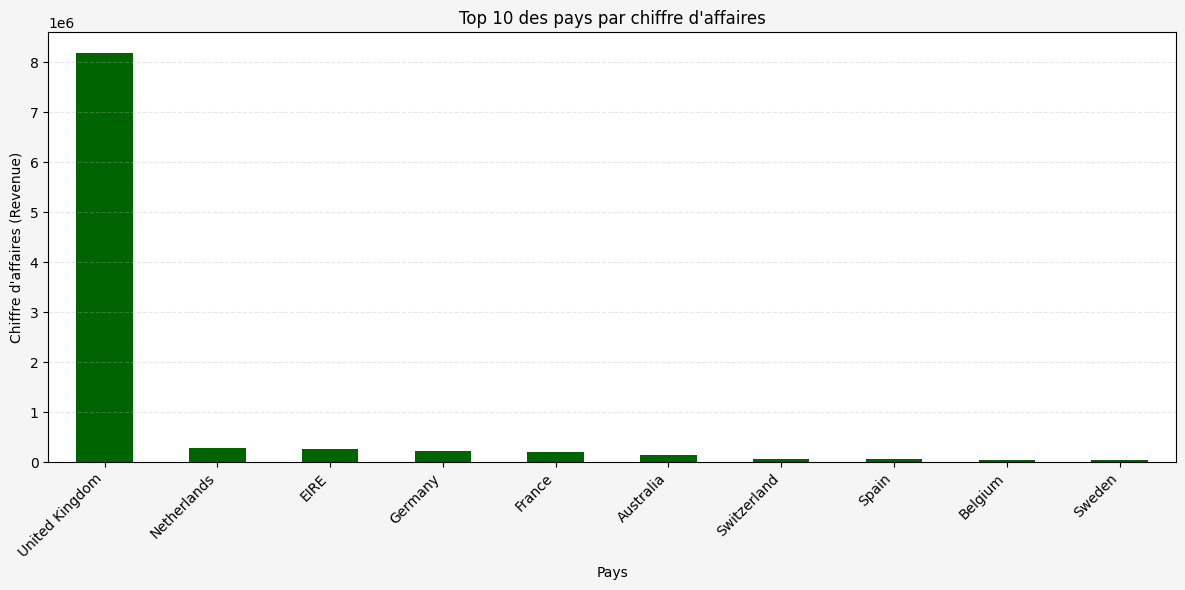

In [50]:
#Visualisation des 10 pays générant le plus de chiffre d'affaire
# Créer une figure avec un fond gris très clair
plt.figure(figsize=(12,6), facecolor="whitesmoke")

# Tracer le graphique
country_revenue.plot(kind="bar", color="darkgreen")

# Ajouter une grille horizontale
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Ajouter le titre et les étiquettes des axes
plt.title("Top 10 des pays par chiffre d'affaires")
plt.xlabel("Pays")
plt.ylabel("Chiffre d'affaires (Revenue)")

# Faire pivoter les noms des pays
plt.xticks(rotation=45, ha="right")

# Ajuster automatiquement la mise en page
plt.tight_layout()

# Afficher le graphique
plt.show()

Insight : Le Royaume-Uni (United Kingdom) domine très largement le chiffre d'affaires de l'entreprise. Il génère un revenu nettement supérieur à celui des autres pays, ce qui montre qu'il constitue le principal marché de l'entreprise. Les Pays-Bas (Netherlands), l'Irlande (EIRE), l'Allemagne (Germany) et la France (France) suivent, mais avec des chiffres d'affaires beaucoup plus faibles.  

Interprétation métier :
Cette forte concentration du chiffre d'affaires sur le marché britannique indique que l'entreprise dépend fortement du Royaume-Uni. Il serait pertinent de :
maintenir et fidéliser les clients du Royaume-Uni, car ils représentent la principale source de revenus ;
mettre en place des actions marketing ciblées pour développer les ventes dans les autres pays (Pays-Bas, Irlande, Allemagne, France, etc.) afin de diversifier les sources de revenus et réduire la dépendance à un seul marché.

# Recommandations  
### 1) Concernant les pays qui génèrent le plus de chiffre d'affaires  
Insight : Le Royaume-Uni domine largement les revenus, suivi par les Pays-Bas, l'Irlande, l'Allemagne et la France.  
Recommandation :  
Maintenir une stratégie de fidélisation forte au Royaume-Uni (offres personnalisées, programme de fidélité).
Développer les marchés secondaires comme l'Allemagne, la France et les Pays-Bas avec des campagnes marketing ciblées.
Réduire la dépendance à un seul pays en diversifiant la clientèle internationale.  


### 2) Concernant les produits les plus vendus en quantité   
Insight : Certains produits ont des volumes de vente beaucoup plus élevés que les autres.  
Recommandation :  
Maintenir un stock suffisant pour les produits très demandés afin d'éviter les ruptures.
Mettre en avant ces produits sur le site (produits populaires, recommandations).
Identifier les caractéristiques des produits qui expliquent leur succès pour développer des produits similaires.  

### 3) Concernant les produits qui génèrent le plus de chiffre d'affaires  
Insight : Les produits qui rapportent le plus ne sont pas forcément ceux qui se vendent le plus en quantité.  
Recommandation :  
Prioriser la gestion des produits à forte rentabilité.
Mettre en place des promotions intelligentes (par exemple : associer un produit très rentable avec un produit populaire).
Surveiller la marge et pas seulement le volume des ventes.  

### 4) Concernant l'évolution mensuelle du chiffre d'affaires  
Insight : Les ventes augmentent fortement vers certains mois, notamment en fin d'année.  
Recommandation :  
Préparer davantage de stock avant les périodes de forte demande.
Lancer des campagnes marketing avant les pics de ventes.
Adapter les ressources (logistique, service client) pendant les périodes chargées.


In [51]:
#Dataset nettoyé
df.to_csv("cleaned_online_retail.csv", index=False)